# Banco de Dados - Plantas de Veiculos Eletricos

Este notebook coleta, valida e salva GHI diario para 10 localidades usando o produto oficial NLR/NSRDB GOES Aggregated PSM v4.

O periodo oficial do projeto e 2019-2024. A rotina confirma a disponibilidade de todos os anos antes da coleta, sem gerar ou completar dados sinteticos.

## Ambiente e funcoes de coleta

In [1]:
# Configura a raiz do projeto para que os imports funcionem no Jupyter.
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "cadernos_jupyter":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from codigo_fonte.preprocessamento import (
    coletar_ghi_nrel,
    consultar_anos_disponiveis_nsrdb,
)
from codigo_fonte.localidades_ev import LOCALIDADES_EV
from treinar_todas_localidades import (
    ANO_FINAL_DADOS,
    ANO_INICIAL_DADOS,
    MANIFESTO_DADOS,
    gerar_manifesto_dados,
    nome_arquivo,
)

## Credenciais

O arquivo `.env` da raiz deve definir `NREL_API_KEY` e `NREL_EMAIL`. Os nomes historicos foram mantidos por compatibilidade com o projeto.

In [2]:
# Carrega as credenciais locais sem grava-las no notebook ou no Git.
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("NREL_API_KEY")
email = os.getenv("NREL_EMAIL")

modo_offline = not key or not email

if modo_offline:
    print("Credenciais NLR nao encontradas. Usando CSVs locais ja coletados.")
else:
    print("Credenciais NLR carregadas do arquivo .env.")

Credenciais NLR nao encontradas. Usando CSVs locais ja coletados.


## Localidades

In [3]:
# Usa o cadastro centralizado para manter nomes e coordenadas consistentes.
localidades = LOCALIDADES_EV

display(pd.DataFrame(localidades))

,nome,pais,lat,lon,endereco,fonte_localidade,fonte_coordenadas,osm_elemento,metodo_coordenadas
0,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,way/319513382,Centroide do elemento da fabrica no OpenStreet...
1,Tesla Gigafactory Nevada,EUA,39.540393,-119.439052,"1 Electric Avenue, Storey County, Nevada 89437...",https://www.tesla.com/contact,https://www.openstreetmap.org/way/422015619,way/422015619,Centroide do elemento da fabrica no OpenStreet...
2,Tesla Gigafactory Texas,EUA,30.221932,-97.618773,"1 Tesla Road, Austin, Texas 78725, EUA",https://www.tesla.com/giga-texas,https://www.openstreetmap.org/way/990257143,way/990257143,Centroide do elemento da fabrica no OpenStreet...
3,Hyundai Metaplant Georgia,EUA,32.160526,-81.450998,"1500 Genesis Drive, Ellabell, Georgia 31308, EUA",https://www.hyundaimotorgroup.com/en/news/CONT...,https://www.openstreetmap.org/way/1207640268,way/1207640268,Centroide do elemento da fabrica no OpenStreet...
4,Rivian Normal,EUA,40.509291,-89.054544,"100 Rivian Motorway, Normal, Illinois 61761, EUA",https://stories.rivian.com/r2-expansion-03-2025,https://www.openstreetmap.org/way/438033786,way/438033786,Centroide do elemento da fabrica no OpenStreet...
5,Tesla Fremont Factory,EUA,37.492690,-121.941508,"45500 Fremont Boulevard, Fremont, California 9...",https://www.tesla.com/contact,https://www.openstreetmap.org/way/38080584,way/38080584,Centroide do elemento da fabrica no OpenStreet...
6,Lucid AMP 1 Casa Grande,EUA,32.856852,-111.778438,"317 S. Thornton Road, Casa Grande, Arizona 851...",https://ir.lucidmotors.com/news-releases/news-...,https://www.openstreetmap.org/way/1254715766,way/1254715766,Centroide do elemento da fabrica no OpenStreet...
7,GM Factory Zero,EUA,42.381512,-83.045342,"2500 East Grand Boulevard, Detroit, Michigan 4...",https://www.gm.com/company/facilities/factory-...,https://www.openstreetmap.org/way/554307172,way/554307172,Centroide do elemento da fabrica no OpenStreet...
8,Ford Rouge Electric Vehicle Center,EUA,42.305623,-83.167633,"Ford River Rouge Complex, Dearborn, Michigan 4...",https://corporate.ford.com/corporate/articles/...,https://www.openstreetmap.org/way/496054397,way/496054397,Centroide do elemento da fabrica no OpenStreet...
9,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,way/553644102,Centroide do elemento da fabrica no OpenStreet...


## Disponibilidade e coleta oficial

In [4]:
# Confirma a disponibilidade dos anos antes da coleta ou carrega os CSVs locais ja existentes.
INTERVALO_MINUTOS = 60
ANO_INICIAL = ANO_INICIAL_DADOS
ANO_FINAL_COLETA = ANO_FINAL_DADOS

output_dir = PROJECT_ROOT / "dados" / "brutos" / "localidades_ev"
dados_localidades = {}

if modo_offline:
    for local in localidades:
        arquivo = output_dir / f"{nome_arquivo(local['nome'])}.csv"
        print(f"Carregando {local['nome']} -> {arquivo.name}")
        dados_localidades[local["nome"]] = pd.read_csv(arquivo, parse_dates=["data"])
    print(f"Dados locais carregados de {output_dir}.")
else:
    referencia = localidades[0]
    anos_disponiveis = consultar_anos_disponiveis_nsrdb(
        referencia["lat"], referencia["lon"], key
    )
    anos_solicitados = set(range(ANO_INICIAL, ANO_FINAL_COLETA + 1))
    anos_indisponiveis = sorted(anos_solicitados - set(anos_disponiveis))
    if anos_indisponiveis:
        raise RuntimeError(
            f"Anos ainda nao publicados no GOES Aggregated PSM v4: {anos_indisponiveis}."
        )

    print(f"Periodo confirmado na API: {ANO_INICIAL}-{ANO_FINAL_COLETA}.")

    for local in localidades:
        arquivo = output_dir / f"{nome_arquivo(local['nome'])}.csv"
        print(f"Coletando {local['nome']} -> {arquivo.name}")
        dados_localidades[local["nome"]] = coletar_ghi_nrel(
            lat=local["lat"],
            lon=local["lon"],
            city=local["nome"],
            pais=local["pais"],
            endereco=local["endereco"],
            fonte_localidade=local["fonte_localidade"],
            fonte_coordenadas=local["fonte_coordenadas"],
            metodo_coordenadas=local["metodo_coordenadas"],
            osm_elemento=local["osm_elemento"],
            start_year=ANO_INICIAL,
            end_year=ANO_FINAL_COLETA,
            inter=INTERVALO_MINUTOS,
            output_path=arquivo,
        )

    print(f"Coleta finalizada e salva em {output_dir}.")

Carregando BYD Camacari -> byd_camacari.csv
Carregando Tesla Gigafactory Nevada -> tesla_gigafactory_nevada.csv
Carregando Tesla Gigafactory Texas -> tesla_gigafactory_texas.csv
Carregando Hyundai Metaplant Georgia -> hyundai_metaplant_georgia.csv
Carregando Rivian Normal -> rivian_normal.csv
Carregando Tesla Fremont Factory -> tesla_fremont_factory.csv
Carregando Lucid AMP 1 Casa Grande -> lucid_amp_1_casa_grande.csv
Carregando GM Factory Zero -> gm_factory_zero.csv


Carregando Ford Rouge Electric Vehicle Center -> ford_rouge_electric_vehicle_center.csv


Carregando BMW San Luis Potosi -> bmw_san_luis_potosi.csv
Dados locais carregados de /workspaces/TCC/dados/brutos/localidades_ev.


## Validacao dos dados coletados

In [5]:
# Une as localidades e valida cobertura, faixa fisica e proveniencia.
ghi_total = pd.concat(dados_localidades.values(), ignore_index=True)
datas_esperadas = pd.date_range(
    f"{ANO_INICIAL}-01-01", f"{ANO_FINAL_COLETA}-12-31", freq="D"
)

cobertura = (
    ghi_total.groupby("localidade")
    .agg(
        registros=("data", "size"),
        inicio=("data", "min"),
        fim=("data", "max"),
        ghi_minimo=("ghi", "min"),
        ghi_medio=("ghi", "mean"),
        ghi_maximo=("ghi", "max"),
    )
    .sort_values("ghi_medio", ascending=False)
)

if not (cobertura["registros"] == len(datas_esperadas)).all():
    raise ValueError("Uma ou mais localidades estao com cobertura diaria incompleta.")
if not ghi_total["ghi"].between(0, 500).all():
    raise ValueError("Foram encontrados valores fora da unidade diaria W/m2.")

manifesto = gerar_manifesto_dados()
print(f"Manifesto SHA-256 atualizado em {MANIFESTO_DADOS}.")

display(cobertura)
display(ghi_total.head())
display(ghi_total.tail())

display(
    ghi_total[[
        "fonte_dados", "produto_dados", "versao_dados",
        "endpoint_api", "intervalo_minutos", "agregacao", "unidade_ghi",
    ]].drop_duplicates()
)

Manifesto SHA-256 atualizado em /workspaces/TCC/dados/brutos/localidades_ev/manifesto_nsrdb.csv.


,registros,inicio,fim,ghi_minimo,ghi_medio,ghi_maximo
localidade,,,,,,
BMW San Luis Potosi,2192,2019-01-01,2024-12-31,27.541667,251.877072,377.000000
Lucid AMP 1 Casa Grande,2192,2019-01-01,2024-12-31,8.666667,245.967609,386.208333
BYD Camacari,2192,2019-01-01,2024-12-31,27.916667,233.990268,348.125000
Tesla Gigafactory Nevada,2192,2019-01-01,2024-12-31,7.916667,222.272335,394.416667
Tesla Fremont Factory,2192,2019-01-01,2024-12-31,12.166667,221.995191,376.333333
Tesla Gigafactory Texas,2192,2019-01-01,2024-12-31,12.250000,208.541705,367.166667
Hyundai Metaplant Georgia,2192,2019-01-01,2024-12-31,7.541667,198.486333,361.083333
Rivian Normal,2192,2019-01-01,2024-12-31,8.750000,172.130779,375.416667
GM Factory Zero,2192,2019-01-01,2024-12-31,3.416667,159.192689,376.916667


,data,ghi,localidade,pais,lat,lon,endereco_localidade,fonte_localidade,fonte_coordenadas,metodo_coordenadas,...,agregacao,unidade_ghi,lat_grade_nsrdb,lon_grade_nsrdb,site_id_nsrdb,source_nsrdb,timezone_nsrdb,elevacao_grade_m,ghi_unidade_api,data_coleta_utc
0,2019-01-01,341.666667,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,-12.67,-38.3,2000061,NSRDB,-3,34,w/m2,2026-06-06T03:43:28.133809+00:00
1,2019-01-02,332.333333,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,-12.67,-38.3,2000061,NSRDB,-3,34,w/m2,2026-06-06T03:43:28.133809+00:00
2,2019-01-03,341.000000,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,-12.67,-38.3,2000061,NSRDB,-3,34,w/m2,2026-06-06T03:43:28.133809+00:00
3,2019-01-04,318.875000,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,-12.67,-38.3,2000061,NSRDB,-3,34,w/m2,2026-06-06T03:43:28.133809+00:00
4,2019-01-05,318.208333,BYD Camacari,Brasil,-12.673377,-38.281234,"Avenida Henry Ford, Polo Industrial, Camacari,...",https://www.byd.com/br/noticias-byd-brasil/byd...,https://www.openstreetmap.org/way/319513382,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,-12.67,-38.3,2000061,NSRDB,-3,34,w/m2,2026-06-06T03:43:28.133809+00:00


,data,ghi,localidade,pais,lat,lon,endereco_localidade,fonte_localidade,fonte_coordenadas,metodo_coordenadas,...,agregacao,unidade_ghi,lat_grade_nsrdb,lon_grade_nsrdb,site_id_nsrdb,source_nsrdb,timezone_nsrdb,elevacao_grade_m,ghi_unidade_api,data_coleta_utc
21915,2024-12-27,222.250000,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,21.97,-100.86,593265,NSRDB,-6,1841,w/m2,2026-06-06T03:48:24.217357+00:00
21916,2024-12-28,223.875000,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,21.97,-100.86,593265,NSRDB,-6,1841,w/m2,2026-06-06T03:48:24.217357+00:00
21917,2024-12-29,222.791667,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,21.97,-100.86,593265,NSRDB,-6,1841,w/m2,2026-06-06T03:48:24.217357+00:00
21918,2024-12-30,225.000000,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,21.97,-100.86,593265,NSRDB,-6,1841,w/m2,2026-06-06T03:48:24.217357+00:00
21919,2024-12-31,216.541667,BMW San Luis Potosi,Mexico,21.968265,-100.849173,"Boulevard BMW 655, Parque Industrial Desarroll...",https://www.bmwgroup-werke.com/san-luis-potosi...,https://www.openstreetmap.org/way/553644102,Centroide do elemento da fabrica no OpenStreet...,...,media_diaria,W/m2,21.97,-100.86,593265,NSRDB,-6,1841,w/m2,2026-06-06T03:48:24.217357+00:00


,fonte_dados,produto_dados,versao_dados,endpoint_api,intervalo_minutos,agregacao,unidade_ghi
0,NLR/NSRDB,GOES Aggregated PSM v4,4.0.0;4.0.1;4.1.2.dev4+g3b38bc8.d20250228,https://developer.nlr.gov/api/nsrdb/v2/solar/n...,60,media_diaria,W/m2


## Series mensais para visualizacao

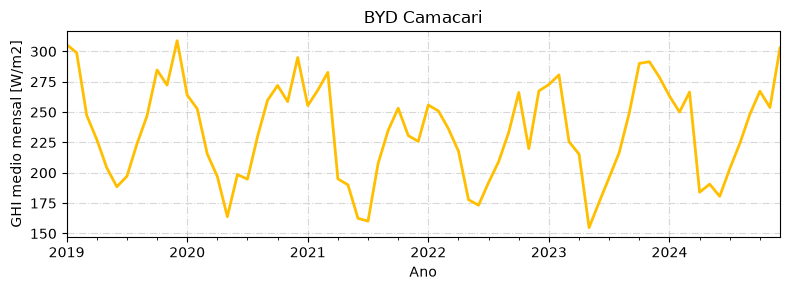

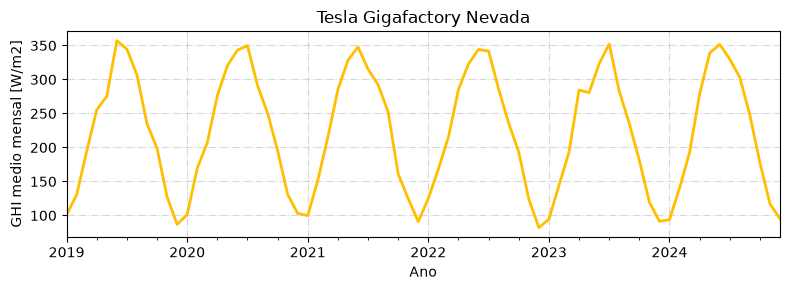

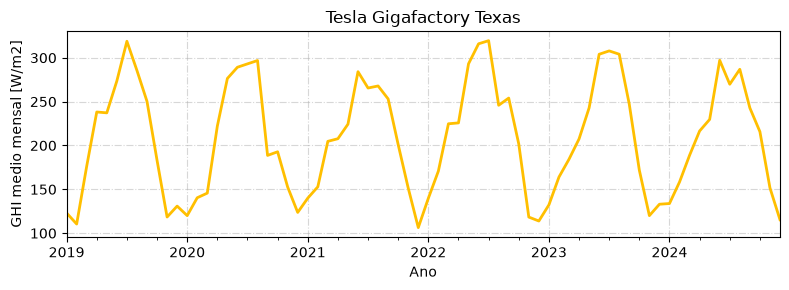

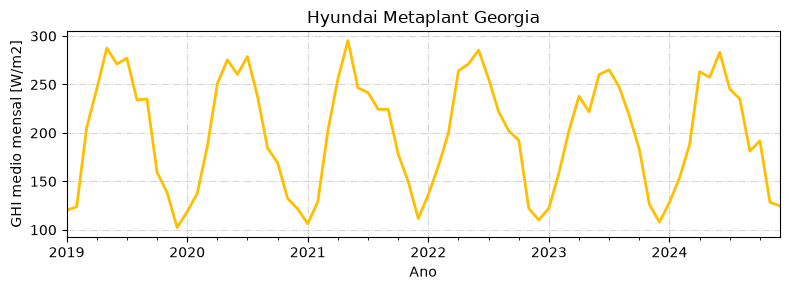

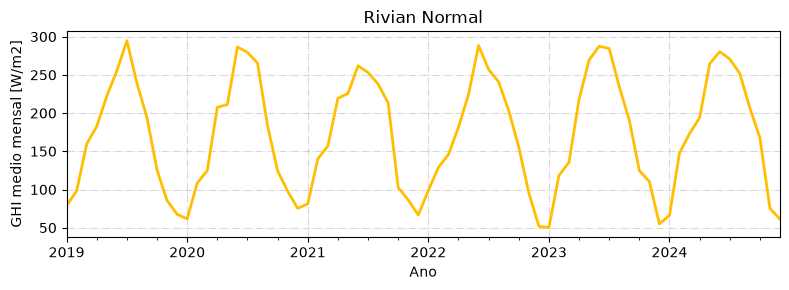

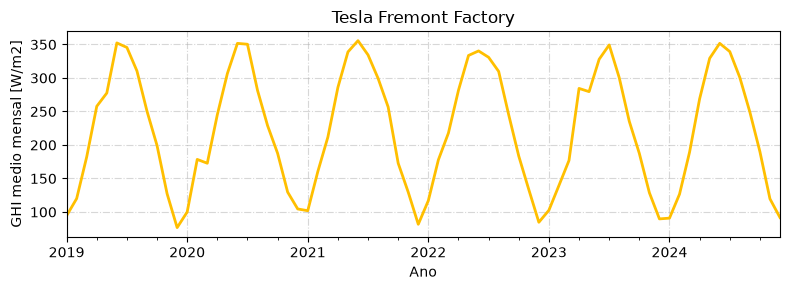

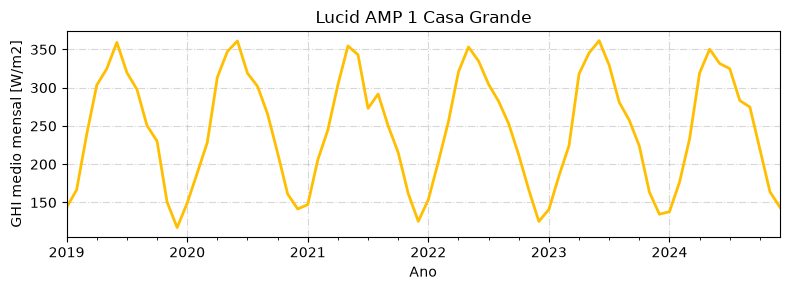

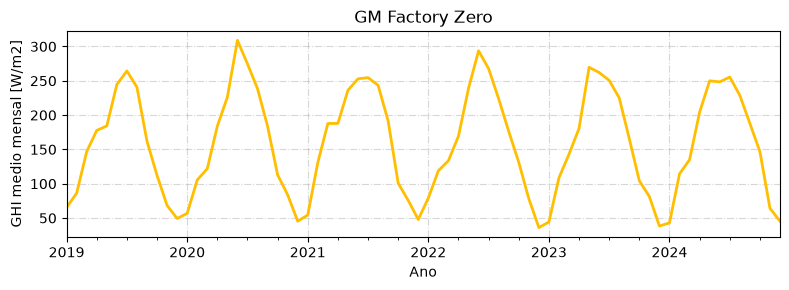

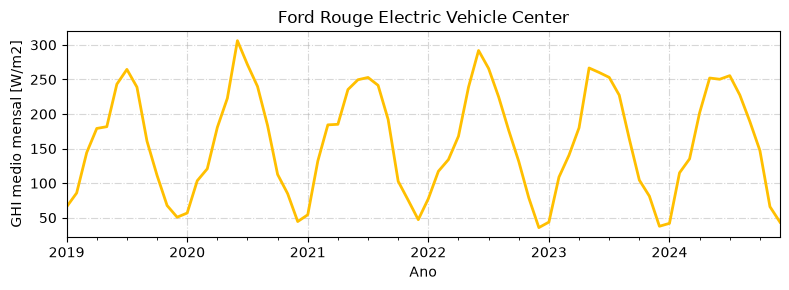

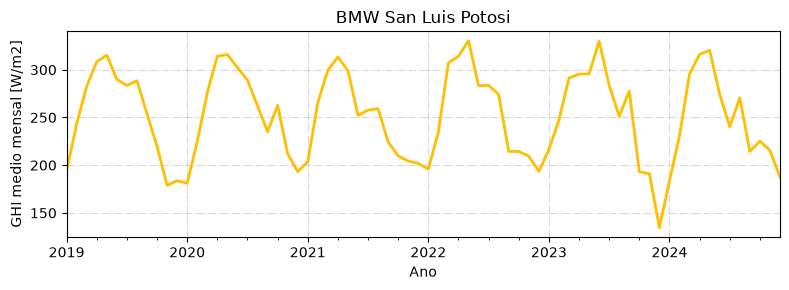

In [6]:
# A media mensal permite visualizar a tendencia e tambem alimenta o fluxo mensal do modelo.
for local in localidades:
    nome = local["nome"]
    mensal = (
        dados_localidades[nome]
        .set_index("data")[["ghi"]]
        .resample("ME")
        .mean()
    )

    fig, ax = plt.subplots(figsize=(8, 3))
    mensal["ghi"].plot(ax=ax, color="#FFBF00", linewidth=2, label="GHI")
    ax.grid(True, alpha=0.5, ls="-.")
    ax.set_xlabel("Ano")
    ax.set_ylabel("GHI medio mensal [W/m2]")
    ax.set_title(nome)
    plt.tight_layout()
    plt.show()

## Comparativo entre localidades

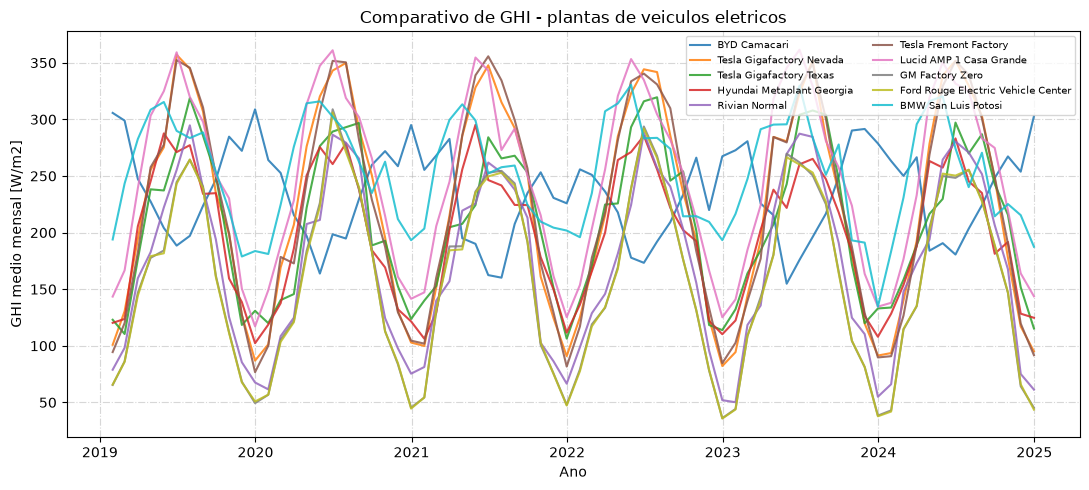

In [7]:
# Sobrepoe as series mensais para comparar sazonalidade entre localidades.
fig, ax = plt.subplots(figsize=(11, 5))

for local in localidades:
    nome = local["nome"]
    mensal = (
        dados_localidades[nome]
        .set_index("data")[["ghi"]]
        .resample("ME")
        .mean()
    )
    ax.plot(mensal.index, mensal["ghi"], linewidth=1.5, alpha=0.85, label=nome)

ax.grid(True, alpha=0.5, ls="-.")
ax.set_xlabel("Ano")
ax.set_ylabel("GHI medio mensal [W/m2]")
ax.set_title("Comparativo de GHI - plantas de veiculos eletricos")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()